In [57]:
# Imports

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# load in the results
result_dir = "/Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/"

date = "2026-03-17/"
slurm_job = 16358208

result_dir = result_dir + date + str(slurm_job) + "/"
# result_dir = result_dir + date + "v/"


stage = "stage3"
envs = [1,2,3]
trials = [1,2,3]
run = 0

withNeurons = False

# batches = [3,4,5,7,8,9,10,11,12,13,14,15,16,17,18,19]
# batches=[1, 7, 9, 11, 12, 15, 16, 18]
batches = [2, 3, 4, 8, 12, 15, 17]

In [ ]:
def read_ith_line(i, filename):
    with open(filename, "r") as file:
        for line_number, line in enumerate(file, start=1):
            if (line_number == i):
                return [float(x) for x in line.strip().split()]
            
    raise ValueError(f"File {filename} has fewer than {i} lines")

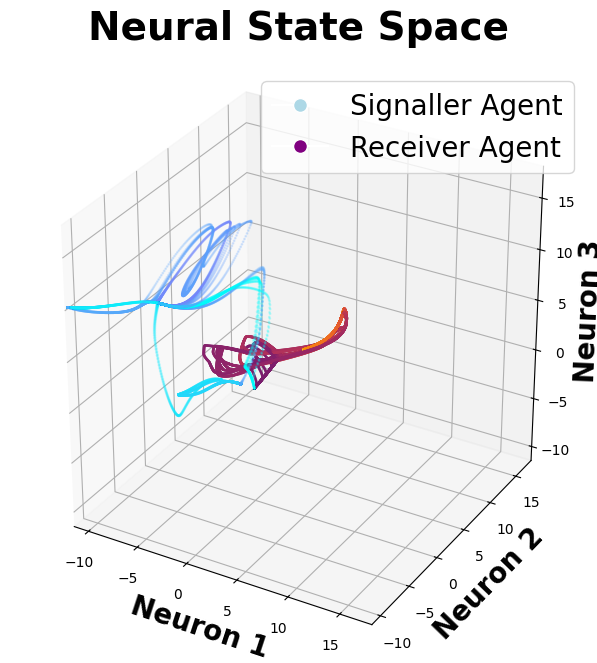

In [68]:
batches = [2]
for batch_index, batch in enumerate(batches):
    signaller_neural_state_1_file = result_dir+ f"batch_{batch}/run_{run}/signaller_neuron1_{stage}_0.dat"
    signaller_neural_state_2_file = result_dir+ f"batch_{batch}/run_{run}/signaller_neuron2_{stage}_0.dat"
    signaller_neural_state_3_file = result_dir+ f"batch_{batch}/run_{run}/signaller_neuron3_{stage}_0.dat"

    receiver_neural_state_1_file = result_dir+ f"batch_{batch}/run_{run}/receiver_neuron1_{stage}_0.dat"
    receiver_neural_state_2_file = result_dir+ f"batch_{batch}/run_{run}/receiver_neuron2_{stage}_0.dat"
    receiver_neural_state_3_file = result_dir+ f"batch_{batch}/run_{run}/receiver_neuron3_{stage}_0.dat"
    fig = plt.figure(figsize=(12, 10))
    ax1 = fig.add_subplot(121, projection='3d')  # Signaller
    # ax2 = fig.add_subplot(122, projection='3d')  # Receiver
    counter = 1

    all_s = []
    all_r = []
    for trial_index, trial in enumerate(trials):
        for env_index, env in enumerate(envs):        
            # get the neural states
            signaler_neuron1 = read_ith_line(counter, signaller_neural_state_1_file)
            signaler_neuron2 = read_ith_line(counter, signaller_neural_state_2_file)
            signaler_neuron3 = read_ith_line(counter, signaller_neural_state_3_file)

            receiver_neuron1 = read_ith_line(counter, receiver_neural_state_1_file)
            receiver_neuron2 = read_ith_line(counter, receiver_neural_state_2_file)
            receiver_neuron3 = read_ith_line(counter, receiver_neural_state_3_file)
            
            all_s.extend([signaler_neuron1,signaler_neuron2,signaler_neuron3])
            all_r.extend([receiver_neuron1,receiver_neuron2,receiver_neuron3])

            time_s = range(len(signaler_neuron1))
            time_r = range(len(receiver_neuron1))

            # signaller is red -> yellow
            # receiver is blue -> greeny
            ax1.scatter(signaler_neuron1, signaler_neuron2, signaler_neuron3, c=time_s, cmap ="cool", alpha=0.2, s=1, label="_Signaller")
            ax1.scatter(receiver_neuron1, receiver_neuron2, receiver_neuron3, c=time_r, cmap="inferno", s=1, alpha =0.6, label="_Receiver")

            # if counter == 1:
            #     ax1.scatter(signaler_neuron1, signaler_neuron2, signaler_neuron3, c=time_s, cmap ="cool", alpha=0.2, s=1, label="Signaller")
            #     ax1.scatter(receiver_neuron1, receiver_neuron2, receiver_neuron3, c=time_r, cmap="inferno", s=1, alpha =0.6, label="Receiver")
            # else:
                
                # ax1.scatter(signaler_neuron1[0], signaler_neuron2[0], signaler_neuron3[0], color="red", s=10, label="Signaller start")
                # ax1.scatter(signaler_neuron1[-1], signaler_neuron2[-1], signaler_neuron3[-1], color="yellow", s=10, label="Signaller end")
                
                # ax2.scatter(receiver_neuron1[0], receiver_neuron2[0], receiver_neuron3[0], color="blue", s=10, label="Receiver start")
                # ax2.scatter(receiver_neuron1[-1], receiver_neuron2[-1], receiver_neuron3[-1], color="green", s=10, label="Receiver end")
            counter +=1
        
    def set_equal_axis(ax, data):
        data = np.concatenate(data)
        min_val = np.min(data)
        max_val = np.max(data)
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        ax.set_zlim(min_val, max_val)
        ax.set_box_aspect([1,1,1])

    set_equal_axis(ax1, all_s)
    # set_equal_axis(ax2, all_r)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
            markerfacecolor='lightblue', markersize=10, label='Signaller Agent'),
        Line2D([0], [0], marker='o', color='w',
            markerfacecolor='purple', markersize=10, label='Receiver Agent'),
    ]

    ax1.legend(handles=legend_elements, frameon=True, fontsize=20)
    for ax in [ax1]:
        ax.set_xlabel("Neuron 1", fontsize=20, fontweight="bold")
        ax.set_ylabel("Neuron 2", fontsize=20, fontweight="bold")
        ax.set_zlabel("Neuron 3", fontsize=20, fontweight="bold")
        ax.set_box_aspect([1,1,1])

        ax1.set_title("Neural State Space", fontsize=28, pad=20, fontweight="bold")
        # ax2.set_title("Receiver Neural State Space")
    # ax1.set_facecolor("#f5f5f5")
    # ax2.set_facecolor("#f5f5f5")
    # ax1.legend()
    plt.tight_layout()

    plt.show()

        



one plot of the neural states by time

/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_16022/1032150866.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


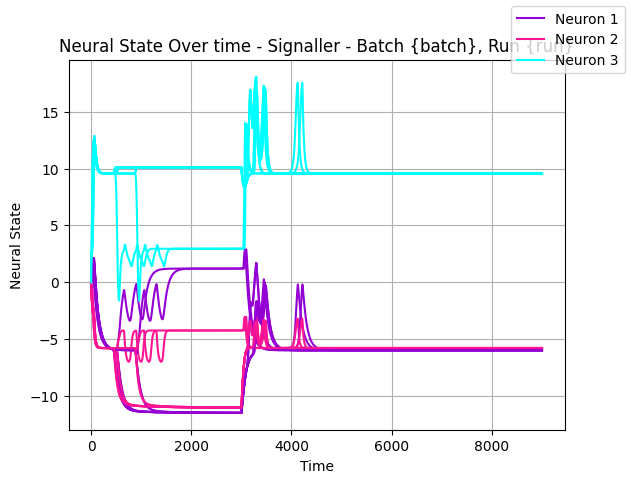

In [ ]:

for batch_index, batch in enumerate(batches):
    fig = plt.figure()
    ax = plt.axes()
    # fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)
    for env_index, env in enumerate(envs):        
        for trial_index, trial in enumerate(trials):
            
            # get the neural states
            signaller_neural_state_1_file = result_dir+ f"batch_{batch}/run_{run}/signaller_neuron1_{stage}_0.dat"
            signaller_neural_state_2_file = result_dir+ f"batch_{batch}/run_{run}/signaller_neuron2_{stage}_0.dat"
            signaller_neural_state_3_file = result_dir+ f"batch_{batch}/run_{run}/signaller_neuron3_{stage}_0.dat"
            
            signaler_neuron1 = read_ith_line(trial*env, signaller_neural_state_1_file)
            signaler_neuron2 = read_ith_line(trial*env, signaller_neural_state_2_file)
            signaler_neuron3 = read_ith_line(trial*env, signaller_neural_state_3_file)
            
            # plot the motor 
            signaler_motor = []

            for p in range(len(signaler_neuron1)):
                signaler_motor.append(signaler_neuron2[p]-signaler_neuron1[p])

            x_signaller_motor = list(range(0, len(signaler_motor)))

            time_s = range(len(signaler_neuron1))

        
            if (env_index == (len(envs)-1) and (trial_index == len(trials)-1)):
                # plot the various neurons + motor
                ax.plot(x_signaller_motor, signaler_neuron1, color="darkviolet", label="Neuron 1")
                ax.plot(x_signaller_motor, signaler_neuron2, color="deeppink", label="Neuron 2")
                ax.plot(x_signaller_motor, signaler_neuron3, color="cyan", label="Neuron 3")
                # ax.plot(x_signaller_motor, signaler_motor, color="springgreen", label="Motor")
            else:
                ax.plot(x_signaller_motor, signaler_neuron1, color="darkviolet", label="_Neuron 1")
                ax.plot(x_signaller_motor, signaler_neuron2, color="deeppink", label="_Neuron 2")
                ax.plot(x_signaller_motor, signaler_neuron3, color="cyan", label="_Neuron 3")
                # ax.plot(x_signaller_motor, signaler_motor, color="springgreen", label="_Motor")

    ax.grid()
    ax.set_xlabel("Time")
    ax.set_ylabel("Neural State")
    fig.legend()
    ax.set_title("Neural State Over time - Signaller - Batch {batch}, Run {run}")
    fig.show()

/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_16022/612321722.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


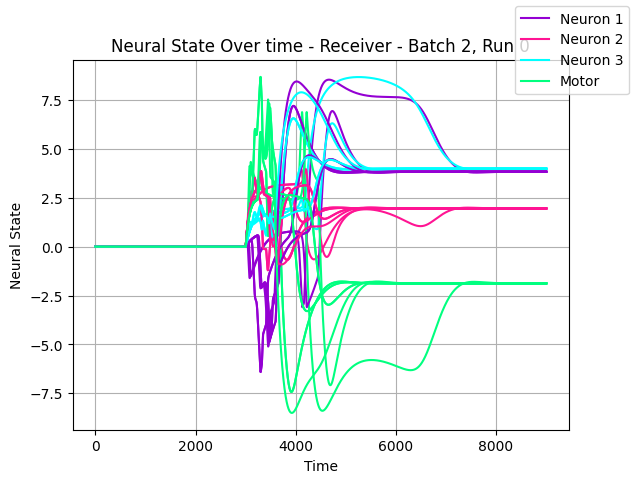

In [ ]:

for batch_index, batch in enumerate(batches):
    fig = plt.figure()
    ax = plt.axes()
    # fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)
    for env_index, env in enumerate(envs):        
        for trial_index, trial in enumerate(trials):
            
            # get the neural states
            receiver_neural_state_1_file = result_dir+ f"batch_{batch}/run_{run}/receiver_neuron1_{stage}_0.dat"
            receiver_neural_state_2_file = result_dir+ f"batch_{batch}/run_{run}/receiver_neuron2_{stage}_0.dat"
            receiver_neural_state_3_file = result_dir+ f"batch_{batch}/run_{run}/receiver_neuron3_{stage}_0.dat"
            
            receiver_neuron1 = read_ith_line(trial*env, receiver_neural_state_1_file)
            receiver_neuron2 = read_ith_line(trial*env, receiver_neural_state_2_file)
            receiver_neuron3 = read_ith_line(trial*env, receiver_neural_state_3_file)
            
            # plot the motor 
            receiver_motor = []

            for p in range(len(receiver_neuron2)):
                receiver_motor.append(receiver_neuron2[p]-receiver_neuron1[p])

            x_receiver_motor = list(range(0, len(receiver_motor)))

            time_s = range(len(receiver_neuron1))

        
            if (env_index == (len(envs)-1) and (trial_index == len(trials)-1)):
                # plot the various neurons + motor
                ax.plot(x_receiver_motor, receiver_neuron1, color="darkviolet", label="Neuron 1")
                ax.plot(x_receiver_motor, receiver_neuron2, color="deeppink", label="Neuron 2")
                ax.plot(x_receiver_motor, receiver_neuron3, color="cyan", label="Neuron 3")
                ax.plot(x_receiver_motor, receiver_motor, color="springgreen", label="Motor")
            else:
                ax.plot(x_receiver_motor, receiver_neuron1, color="darkviolet", label="_Neuron 1")
                ax.plot(x_receiver_motor, receiver_neuron2, color="deeppink", label="_Neuron 2")
                ax.plot(x_receiver_motor, receiver_neuron3, color="cyan", label="_Neuron 3")
                ax.plot(x_receiver_motor, receiver_motor, color="springgreen", label="_Motor")

    ax.grid()
    ax.set_xlabel("Time")
    ax.set_ylabel("Neural State")
    fig.legend()
    ax.set_title(f"Neural State Over time - Receiver - Batch {batch}, Run {run}")
    fig.show()